In [ ]:
""" well, today we will learn the basic usage of expanding the window,
well, we have seen that it is quite similar to the usage of rolling, but you just can not set as comprehensive as the rolling
你 没办法设定右边闭还是全闭，又或者是左闭，expanding 默认右边闭，如果取不到expanding（）里面的数的话，会返回Nan
expanding 是从窗口开始到当前序列的累计窗口，expanding.().mean()等价 cumsum.()/np.arange(1,len+1)
在计算离散的累计收益率的时候，可以使用 (1+returns).cumprod(),
累计波动率可以使用 expanding.().std()
回测净值曲线的时候，可以使用expanding.().apply() ，但是这样操作的时候，每多一个点，就要多运行一次，效率非常慢

"""

# 接上一天的 df_returns 和 df_price

# 【任务 5】计算每只股票的累积收益率（从第一天到现在）
# 要求：使用 (1 + returns).cumprod()
# --- 你的代码 ---

# 答案对照区
# cum_returns = (1 + df_returns).cumprod()
# cum_returns.plot(title='Cumulative Returns')

# 【任务 6】计算累积波动率（从第一天到现在的波动率）
# 要求：使用 expanding().std(ddof=0) 并年化
# 观察：波动率是否随时间收敛？
# --- 你的代码 ---

# cum_vol = df_returns.expanding().std(ddof=0) * np.sqrt(252)
# cum_vol.plot(title='Cumulative Volatility (Annualized)')

# 【任务 7】对比 expanding 和 rolling 在计算均值时的结果差异
# 要求：计算 20 日滚动均值 vs 累积均值，画出对比图
# --- 你的代码 ---

# rolling_mean = df_returns.rolling(20).mean()
# expanding_mean = df_returns.expanding().mean()
# 
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(rolling_mean['AAPL'], label='20-Day Rolling Mean', alpha=0.7)
# ax.plot(expanding_mean['AAPL'], label='Expanding Mean', alpha=0.7)
# ax.legend()
# ax.set_title('AAPL: Rolling vs Expanding Mean')

# 【任务 8】计算累积最大回撤（从历史最高点到当前的回撤）
# 提示：
# 1. 计算历史最高价：df_price.cummax()
# 2. 当前回撤 = (df_price - cummax) / cummax
# 3. 这个不需要 expanding().apply()，直接向量化即可
# --- 你的代码 ---

# cummax = df_price.cummax()
# drawdown = (df_price - cummax) / cummax
# drawdown.plot(title='Drawdown from Historical High')

"""
# 在 RiskMetrics 类中添加以下方法

def cumulative_returns(self) -> pd.DataFrame:
    """计算累积收益率"""
    return (1 + self.returns).cumprod()

def expanding_volatility(self, annualize: bool = True) -> pd.DataFrame:
    """计算累积波动率（从起始到当前）"""
    vol = self.returns.expanding().std(ddof=0)
    if annualize:
        vol = vol * np.sqrt(252)
    return vol

def current_drawdown(self) -> pd.DataFrame:
    """计算当前回撤（相对于历史最高点）"""
    cummax = self.prices.cummax()
    return (self.prices - cummax) / cummax

def expanding_sharpe(self, rf_rate: float = 0.0) -> pd.DataFrame:
    """计算累积夏普比率"""
    rf_daily = rf_rate / 252
    excess = self.returns - rf_daily
    
    cum_mean = excess.expanding().mean() * 252
    cum_std = excess.expanding().std(ddof=0) * np.sqrt(252)
    
    return cum_mean / cum_std

# 在 test_risk_metrics.ipynb 中继续
import matplotlib.pyplot as plt

# 计算累积指标
cum_ret = rm.cumulative_returns()
exp_vol = rm.expanding_volatility()
cur_dd = rm.current_drawdown()
exp_sharpe = rm.expanding_sharpe()

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
#输出一个两行两列的输出面板
cum_ret.plot(ax=axes[0, 0], title='Cumulative Returns')
# ax = axes[0,0]表示一行一列
exp_vol.plot(ax=axes[0, 1], title='Expanding Volatility (Ann.)')
cur_dd.plot(ax=axes[1, 0], title='Current Drawdown')
exp_sharpe.plot(ax=axes[1, 1], title='Expanding Sharpe Ratio')

plt.tight_layout()
#自动调整子图间距，防止标题，坐标轴等叠在一起
plt.show()
#在vscode里面展示
"""



In [2]:
import pandas as pd
import numpy as np
import os

np.random.seed(42)

dates = pd.date_range('2025-01-01',periods = 252, freq = 'B')
tickers = ['AMZN','AAPL','MSFT','NDVA']
prices = {}

for ticker in tickers:
    returns = np.random.randn(252)*0.02
    prices[ticker] = 100*np.exp(np.cumsum(returns))

df_prices = pd.DataFrame(prices,index = dates)
df_returns = df_prices.pct_change().dropna()

df_prices
    

,AMZN,AAPL,MSFT,NDVA
2025-01-01,100.998379,104.335671,98.707145,100.991519
2025-01-02,100.719476,106.512528,97.750159,101.365548
2025-01-03,102.032660,103.324572,96.598861,99.640241
2025-01-06,105.188455,102.328736,94.943989,101.045641
2025-01-07,104.697002,104.954693,95.036171,99.888998
...,...,...,...,...
2025-12-12,94.599004,109.128391,65.561305,201.368103
2025-12-15,97.998878,111.168675,64.294121,204.199826
2025-12-16,98.795856,115.496125,65.663356,205.813159
2025-12-17,96.335606,112.310305,64.428305,209.531194


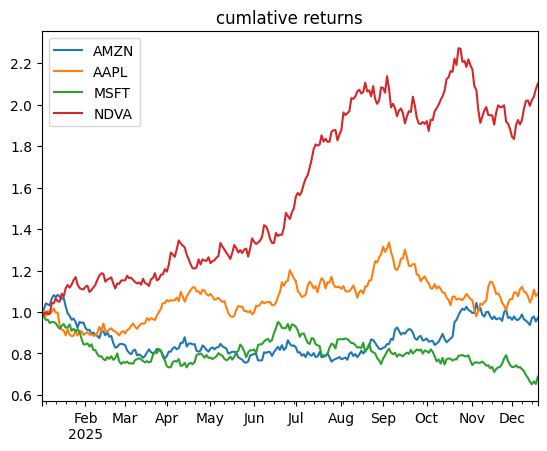

In [6]:
returns = (1+df_returns).cumprod()
cum_returns = returns.plot(title = 'cumlative returns')
#这里是用来绘制图形

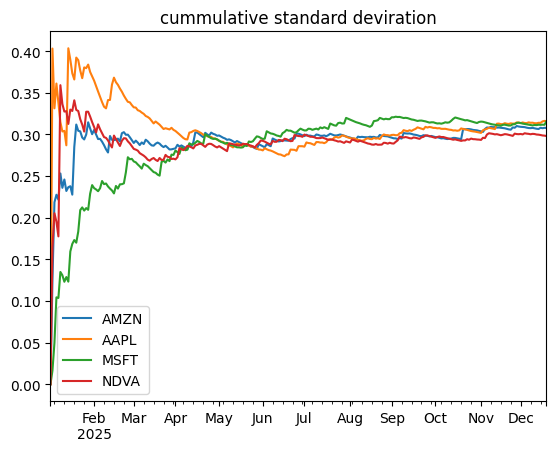

In [10]:
stds = df_returns.expanding().std(ddof = 0)*np.sqrt(252)
cum_stds = stds.plot(title = 'cummulative standard deviration')

Text(0.5, 1.0, 'AAPL:rolling_mean vs expanding_mean')

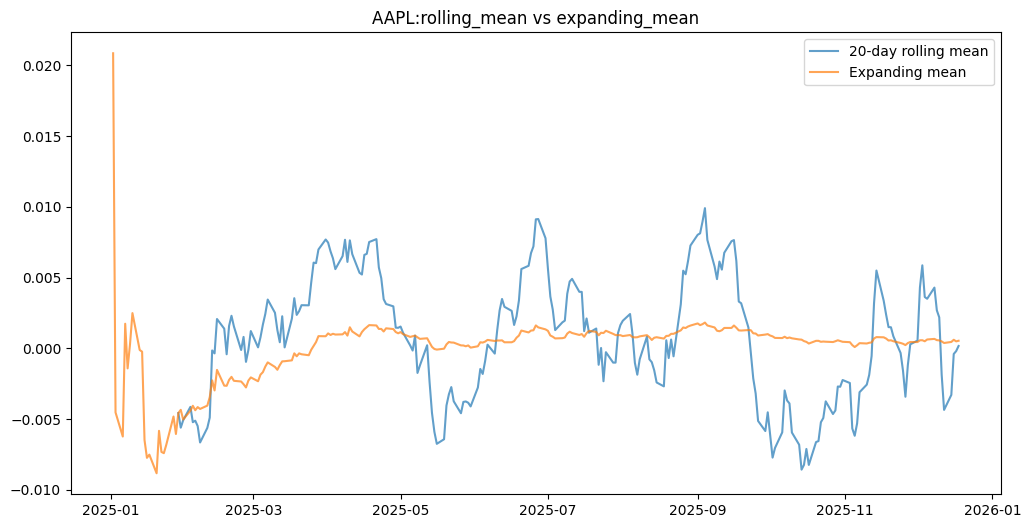

In [13]:
rolling_mean = df_returns.rolling(20).mean()
expanding_mean = df_returns.expanding().mean()

import matplotlib.pyplot as plt
#导入matplotlib 绘图库
fig,ax = plt.subplots(figsize = (12,6))
#创建画布和子图，画布的宽为12，高为6
ax.plot(rolling_mean['AAPL'],label = '20-day rolling mean', alpha = 0.7)
#绘制曲线，alpha = 0.7 表示曲线的透明度为0.7
ax.plot(expanding_mean['AAPL'],label = 'Expanding mean', alpha = 0.7)
ax.legend()
#展示图例，这两条曲线分别表示什么
ax.set_title('AAPL:rolling_mean vs expanding_mean')

<Axes: title={'center': 'Drawdown from Historical High'}>

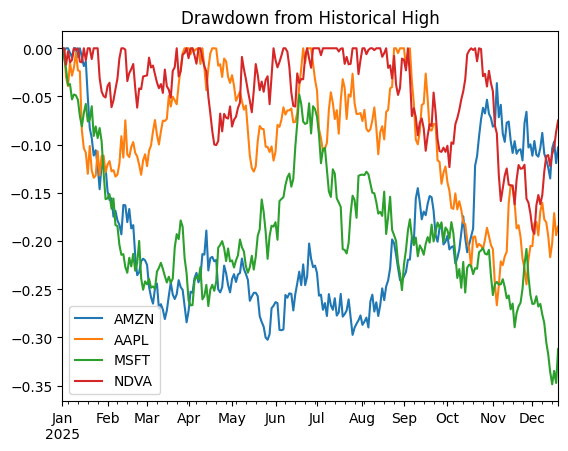

In [21]:
cummax = df_prices.cummax()
drawdown = (df_prices - cummax) / cummax
drawdown.plot(title='Drawdown from Historical High')